# TD learning gamma sweep: leave-probability heatmaps

Loads the 15 completed runs from `bash_scripts/train_gamma_sweep.sh` (5 gammas x 3 networks) and, for
each patch type, plots a 5x3 grid of P(leave) heatmaps. Rows are gamma (increasing top -> bottom),
columns are the 3 networks trained at that gamma. Two grids per patch type: failures measured as
**consecutive** failures, and as **cumulative** failures (both vs. cumulative rewards), matching
`plot_stop_fraction` in the behavioral notebooks.

In [201]:
%load_ext autoreload
%autoreload 

import os, sys, glob, re
sys.path.insert(0, os.path.abspath('..'))     # code/  (behavioral_plotting, ...)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jax
jax.config.update('jax_platforms', 'cpu')
plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import load_odor_site_df, odor_colors
from aux_funcs import format_plot

REPO = os.path.abspath('../..')               # repo root
GAMMAS   = [0.5, 0.8, 0.95, 0.99, 0.999]       # top -> bottom
SUFFIXES = ['0p5', '0p8', '0p95', '0p99', '0p999']
NETS     = [0, 1, 2]

# Every plot in this notebook is also written here as an SVG.
SAVE_DIR = os.path.join(REPO, 'results', 'td_learning_sweep')
os.makedirs(SAVE_DIR, exist_ok=True)

def _tag(label):
    """filename-safe tag for a sweep label ('$\\gamma$' -> 'gamma', 'n_steps' -> 'n_steps')."""
    if 'gamma' in label:
        return 'gamma'
    return re.sub(r'[^0-9a-zA-Z]+', '_', label).strip('_') or 'plot'

def save_svg(fig, name):
    """save `fig` to results/td_learning_sweep/<name>.svg (tight bbox)."""
    path = os.path.join(SAVE_DIR, f'{name}.svg')
    fig.savefig(path, format='svg', bbox_inches='tight')
    print(f'saved {os.path.relpath(path, REPO)}')
    return fig

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Locate the 15 trajectory files

Each run saved a training snapshot under `results/<exp>/step_*/traj_*.pkl`.

In [202]:
def traj_path(suffix, net):
    exp = f'fixed_exp_gru_initial_prob_offset_gamma_{suffix}_net{net}'
    hits = sorted(glob.glob(f'{REPO}/results/{exp}/step_*/traj_*.pkl'))
    if not hits:
        raise FileNotFoundError(f'no trajectory pkl for {exp}')
    return hits[-1]   # latest snapshot

paths = [[traj_path(suf, net) for net in NETS] for suf in SUFFIXES]
for suf, row in zip(SUFFIXES, paths):
    print(f'gamma {suf}: ' + ', '.join(os.path.relpath(p, REPO) for p in row))
print('total files:', sum(len(r) for r in paths))

gamma 0p5: results/fixed_exp_gru_initial_prob_offset_gamma_0p5_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p5_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p5_net2/step_00/traj_000499.pkl
gamma 0p8: results/fixed_exp_gru_initial_prob_offset_gamma_0p8_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p8_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p8_net2/step_00/traj_000499.pkl
gamma 0p95: results/fixed_exp_gru_initial_prob_offset_gamma_0p95_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p95_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p95_net2/step_00/traj_000499.pkl
gamma 0p99: results/fixed_exp_gru_initial_prob_offset_gamma_0p99_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p99_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p

## Load all 15 odor-site dataframes (heavy: parses each run)

In [203]:
# dfs_grid[r][c] = dataframe for GAMMAS[r], network c
dfs_grid = [
    [load_odor_site_df(paths[r][c], nn_num=c, brief=False) for c in range(len(NETS))]
    for r in range(len(GAMMAS))
]
print('loaded', sum(len(row) for row in dfs_grid), 'dataframes')

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
loaded 15 dataframes


## Heatmap helpers

`leave_matrix` reproduces `plot_stop_fraction`'s P(leave) = 1 - mean(stopped) pivot for one df and
patch type; `x_col='consecutive_misses'` or `'cumulative_misses'` (the latter computed per patch as
`cumcount() - rewards_seen_in_patch`). `plot_leave_grid` tiles these into the 5x3 grid.

In [204]:
def leave_matrix(df, x_col, patch_type, y_col='rewards_seen_in_patch', min_n=5):
    d = df[df['patch_type'] == patch_type].copy()
    if x_col == 'cumulative_misses':
        d['cumulative_misses'] = (
            d.groupby(['session_number', 'patch_number']).cumcount() - d[y_col]
        ).clip(lower=0)
    filt = d.groupby([y_col, x_col]).filter(lambda g: len(g) >= min_n)
    grouped = filt.groupby([y_col, x_col])['stopped'].mean().reset_index()
    mat = grouped.pivot(index=y_col, columns=x_col, values='stopped')
    return 1.0 - mat   # P(leave)


def plot_leave_grid(dfs_grid, gammas, patch_type, x_col, x_label, min_n=5,
                    gamma_min=0.95, cmap='YlGnBu', vmin=0, vmax=1,
                    label_fontsize=12, tick_fontsize=10, row_label='$\\gamma$'):
    def _thin_ticks(ax, x_vals, y_vals, max_ticks=6, show_labels=True):
        for vals, set_t, set_l in [(x_vals, ax.set_xticks, ax.set_xticklabels),
                                   (y_vals, ax.set_yticks, ax.set_yticklabels)]:
            n = len(vals)
            if n == 0:
                continue
            step = max(1, int(np.ceil(n / max_ticks)))
            idx = np.arange(0, n, step)
            set_t(idx + 0.5)
            set_l([f'{vals[i]:g}' for i in idx] if show_labels else [],
                  fontsize=tick_fontsize, rotation=0)

    # (4) only gammas >= gamma_min
    rows = [i for i, g in enumerate(gammas) if g >= gamma_min]
    gammas_sel = [gammas[i] for i in rows]
    grid = [dfs_grid[i] for i in rows]
    nrows, ncols = len(gammas_sel), len(grid[0])

    # matrices reindexed to a common (y, x) grid -> shared x/y limits
    mats = [[leave_matrix(grid[r][c], x_col, patch_type, min_n=min_n)
             for c in range(ncols)] for r in range(nrows)]
    all_idx = sorted(set().union(*(set(m.index) for row in mats for m in row)))
    all_col = sorted(set().union(*(set(m.columns) for row in mats for m in row)))
    mats = [[m.reindex(index=all_idx, columns=all_col) for m in row] for row in mats]

    # extra column: P(leave) averaged across networks. A plain mean propagates NaN, so a cell is
    # kept only where EVERY network has a value there.
    def avg_across(row_mats):
        avg = np.stack([m.values for m in row_mats]).mean(axis=0)
        return pd.DataFrame(avg, index=all_idx, columns=all_col)
    avg_mats = [avg_across(mats[r]) for r in range(nrows)]

    ncols_plot = ncols + 1                                       # networks + across-network average
    fig, axes = plt.subplots(nrows, ncols_plot, figsize=(ncols_plot * 2.7, nrows * 2.4))
    axes = np.atleast_2d(axes)
    for r, gamma in enumerate(gammas_sel):
        row_mats = mats[r] + [avg_mats[r]]
        for c in range(ncols_plot):
            ax = axes[r, c]
            sns.heatmap(row_mats[c], ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False)
            ax.invert_yaxis()
            # tick labels only on the bottom-left corner subplot
            _thin_ticks(ax, all_col, all_idx, show_labels=True)
            if r == 0:
                ax.set_title(f'net {c}' if c < ncols else 'avg (all 3)', fontsize=10)
            ax.set_xlabel(x_label if r == nrows - 1 else '', fontsize=label_fontsize)
            ax.set_ylabel(f'{row_label} = {gamma}\nCumulative rewards' if c == 0 else '', fontsize=label_fontsize)

    format_plot(axes, ticklabelsize=tick_fontsize, axislabelsize=label_fontsize, ticklength=4, bottomspine=False, leftspine=False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax)); sm.set_array([])
    cb = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label='P(leave)')
    cb.outline.set_visible(False)
    fig.suptitle(f'patch type {patch_type}:  {x_label} vs cumulative rewards', fontsize=14, y=1.005)
    save_svg(fig, f'leave_grid_{_tag(row_label)}_patch{patch_type}_{x_col}')
    plt.show()
    return fig

## Patch type 1

saved results/td_learning_sweep/leave_grid_gamma_patch1_consecutive_misses.svg


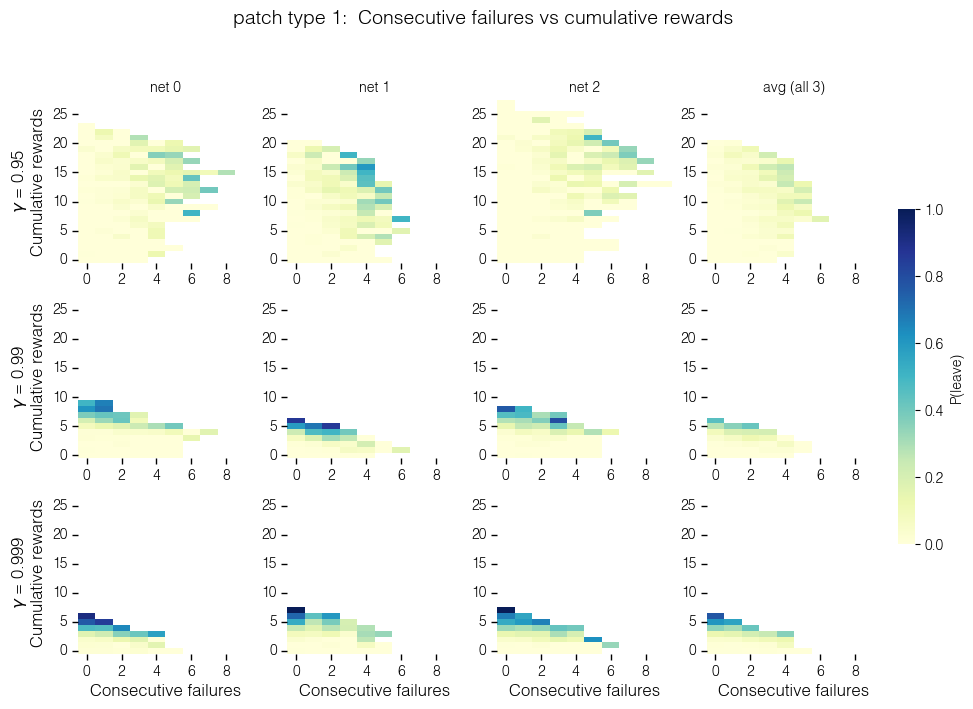

In [205]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=1,
                x_col='consecutive_misses', x_label='Consecutive failures');

saved results/td_learning_sweep/leave_grid_gamma_patch1_cumulative_misses.svg


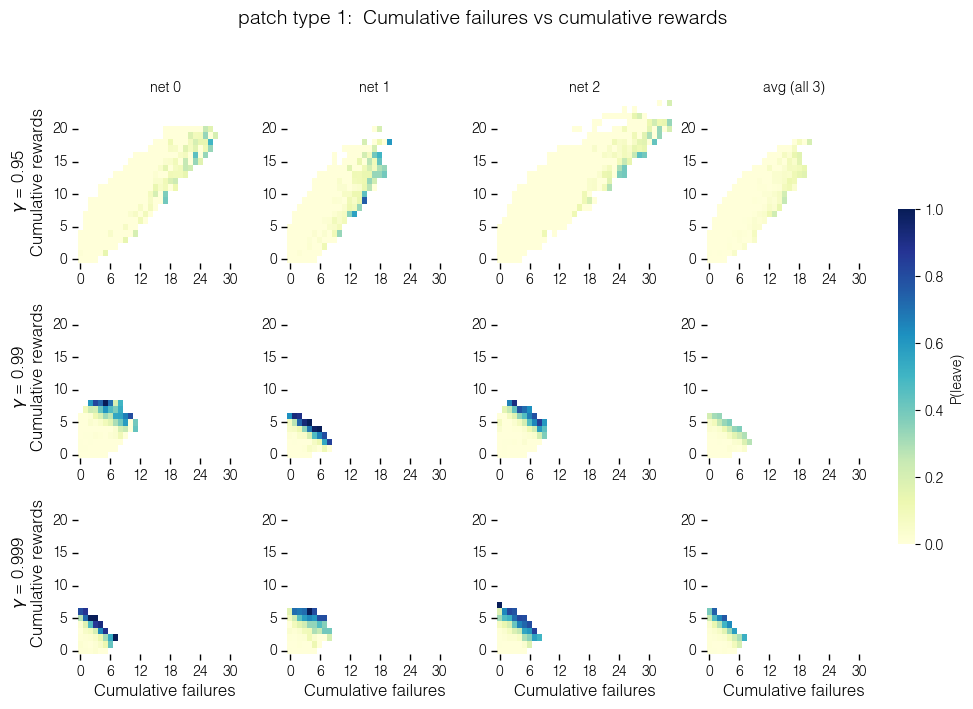

In [206]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=1,
                x_col='cumulative_misses', x_label='Cumulative failures');

## Patch type 2

saved results/td_learning_sweep/leave_grid_gamma_patch2_consecutive_misses.svg


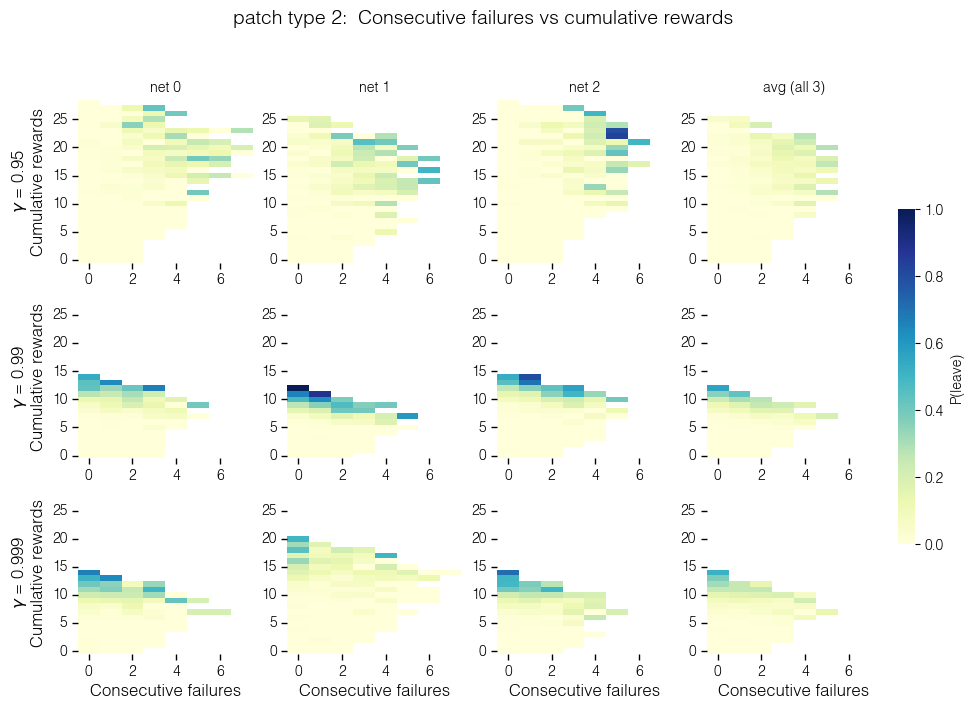

In [207]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=2,
                x_col='consecutive_misses', x_label='Consecutive failures');

saved results/td_learning_sweep/leave_grid_gamma_patch2_cumulative_misses.svg


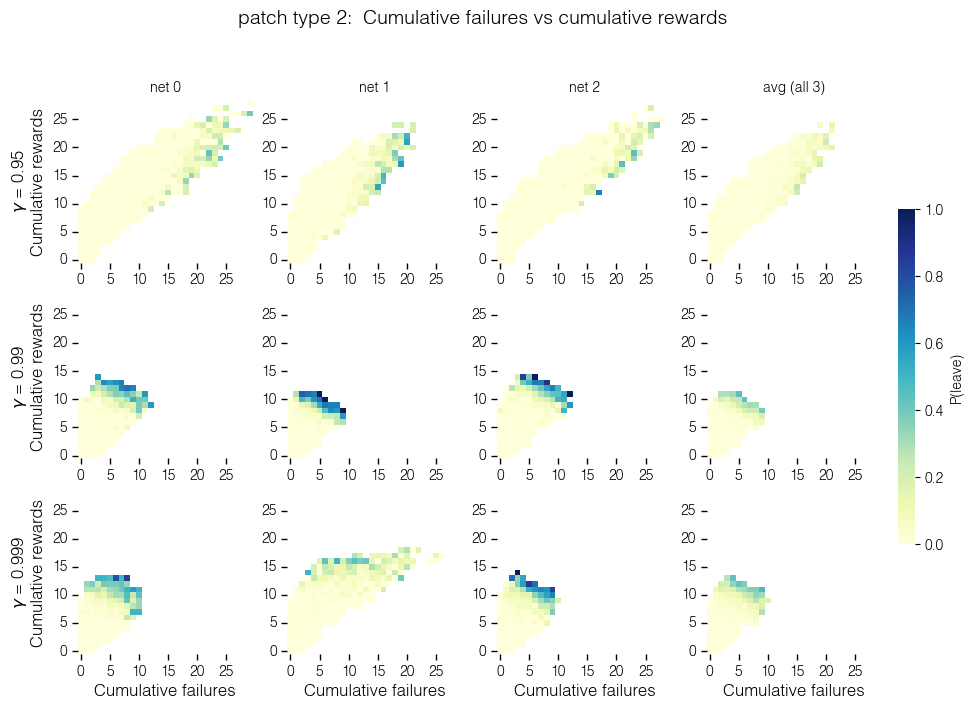

In [208]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=2,
                x_col='cumulative_misses', x_label='Cumulative failures');

## Patch trajectories (color-coded by stop / reward outcome)

Same 3x3 grid (gamma x network). Each subplot is a **patch number x site index** matrix for the
first `n_patches` patches of the given type: **green** = rewarded stop, **grey** = unrewarded stop,
**red** = opt out (the agent did not stop). White = the patch had no site at that index.

In [209]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def patch_cat_matrix(df, patch_type, n_patches):
    """(n_patches, n_sites) matrix of per-site outcome categories for the first n patches of a type.
    -1 = no site, 0 = opt out, 1 = unrewarded stop, 2 = rewarded stop."""
    d = df[df['patch_type'] == patch_type].copy()
    d['site_index'] = d.groupby(['session_number', 'patch_number']).cumcount()
    # a stop is rewarded iff cumulative rewards_seen_in_patch increases at the next site in the
    # patch. (The per-site 'rewarded' column is unreliable -- it desyncs from rewards_seen_in_patch.)
    rs_next = d.groupby(['session_number', 'patch_number'])['rewards_seen_in_patch'].shift(-1)
    d['site_rewarded'] = (rs_next - d['rewards_seen_in_patch']) > 0
    d['patch_id'] = d.groupby(['session_number', 'patch_number']).ngroup()
    ids = list(dict.fromkeys(d['patch_id']))[:n_patches]        # first n patches (temporal order)
    sel = d[d['patch_id'].isin(ids)].copy()
    sel['row'] = sel['patch_id'].map({p: i for i, p in enumerate(ids)})
    stopped = sel['stopped'].values == 1
    cat = np.where(stopped, np.where(sel['site_rewarded'].values, 2, 1), 0)
    n_sites = int(sel['site_index'].max()) + 1 if len(sel) else 1
    M = np.full((n_patches, n_sites), -1, dtype=int)
    M[sel['row'].values, sel['site_index'].values.astype(int)] = cat
    return M


def plot_patch_traj_grid(dfs_grid, gammas, patch_type, n_patches=40, gamma_min=0.95, gamma_max=1.0,
                         col_width=4, gap=1, label_fontsize=12, tick_fontsize=10, row_label='$\\gamma$'):
    rows = [i for i, g in enumerate(gammas) if (g >= gamma_min and g <= gamma_max)]
    gammas_sel = [gammas[i] for i in rows]
    grid = [dfs_grid[i] for i in rows]
    nrows, ncols = len(gammas_sel), len(grid[0])

    mats = [[patch_cat_matrix(grid[r][c], patch_type, n_patches) for c in range(ncols)]
            for r in range(nrows)]
    # each row gets its own site (y) axis limit
    row_sites = [max((m.shape[1] for m in mats[r]), default=1) for r in range(nrows)]

    cat_colors = {2: odor_colors[patch_type], 1: '#dddddd', 0: '#ac37fa'}   # light grey / bright red

    def to_img(M, n_sites):
        # pad sites to this row's limit, transpose so columns = patches, colorize, then widen
        # columns + white gaps
        P = np.full((n_patches, n_sites), -1, dtype=int)
        P[:, :M.shape[1]] = M
        base = np.ones((n_sites, n_patches, 3))                # white; rows = site, cols = patch
        Pt = P.T
        for cat, col in cat_colors.items():
            base[Pt == cat] = mcolors.to_rgb(col)
        W = n_patches * col_width + (n_patches - 1) * gap
        img = np.ones((n_sites, W, 3))
        for p in range(n_patches):
            x = p * (col_width + gap)
            img[:, x:x + col_width, :] = base[:, p][:, None, :]
        return img

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.7, nrows * 2.4))
    axes = np.atleast_2d(axes)
    for r, gamma in enumerate(gammas_sel):
        for c in range(ncols):
            ax = axes[r, c]
            ax.imshow(to_img(mats[r][c], row_sites[r]), aspect='auto', interpolation='nearest')
            ax.set_title(f'net {c}' if r == 0 else '', fontsize=10)
            ax.set_xlabel('patch #' if r == nrows - 1 else '', fontsize=label_fontsize)
            ax.set_ylabel(f'{row_label} = {gamma}\nsite index' if c == 0 else '', fontsize=label_fontsize)
            ax.invert_yaxis()

    format_plot(axes, ticklabelsize=tick_fontsize, axislabelsize=label_fontsize)
    # y ticks on the leftmost column of every row (each row has its own site limit); x ticks only on
    # the bottom-left corner subplot
    for r in range(nrows):
        n_sites = row_sites[r]
        for c in range(ncols):
            ax = axes[r, c]
            if c == 0:
                sidx = np.arange(0, n_sites, max(1, int(np.ceil(n_sites / 6))))
                ax.set_yticks(sidx)
                ax.set_yticklabels([str(x) for x in sidx], fontsize=tick_fontsize)
            else:
                ax.tick_params(labelleft=False)
            if r == nrows - 1 and c == 0:
                pidx = np.arange(0, n_patches, max(1, int(np.ceil(n_patches / 6))))
                ax.set_xticks(pidx * (col_width + gap) + (col_width - 1) / 2)
                ax.set_xticklabels([str(p) for p in pidx], fontsize=tick_fontsize)
            else:
                ax.tick_params(labelbottom=False)

    handles = [mpatches.Patch(color=cat_colors[2], label='rewarded stop'),
               mpatches.Patch(color=cat_colors[1], label='unrewarded stop'),
               mpatches.Patch(color=cat_colors[0], label='opt out')]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
               fontsize=11, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f'patch type {patch_type}:  patch trajectories', fontsize=14, y=1.005)
    save_svg(fig, f'patch_traj_{_tag(row_label)}_patch{patch_type}_np{n_patches}_g{gamma_min:g}-{gamma_max:g}')
    plt.show()
    return fig

saved results/td_learning_sweep/patch_traj_gamma_patch1_np8_g0-0.9.svg


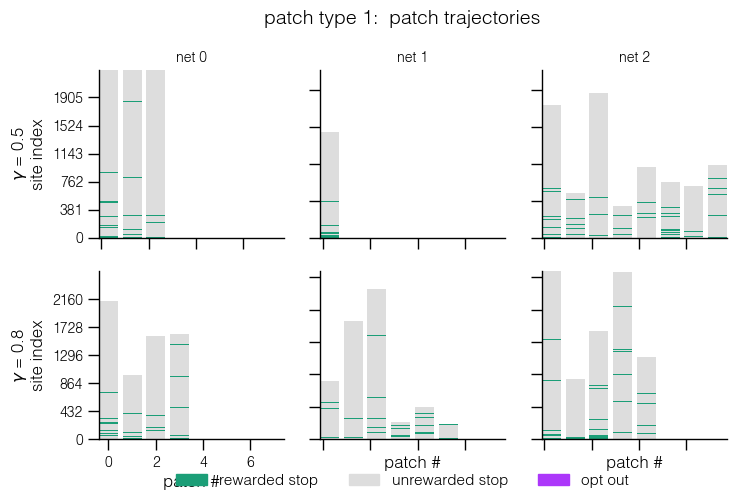

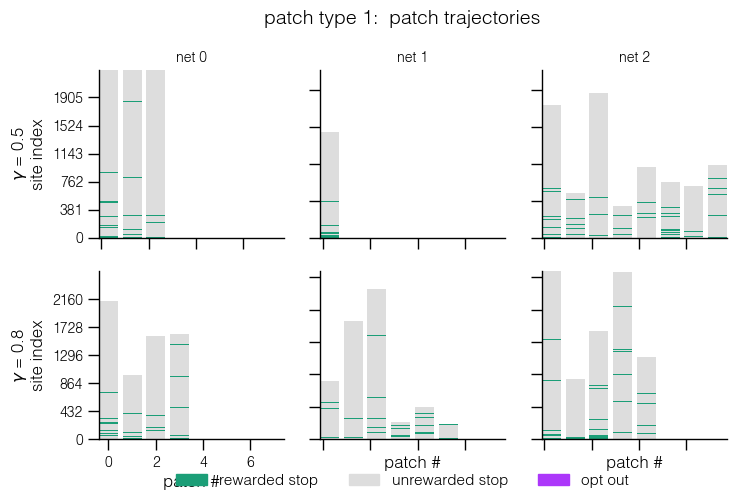

In [210]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=1, n_patches=8, gamma_min=0, gamma_max=0.9)

saved results/td_learning_sweep/patch_traj_gamma_patch1_np40_g0.95-1.svg


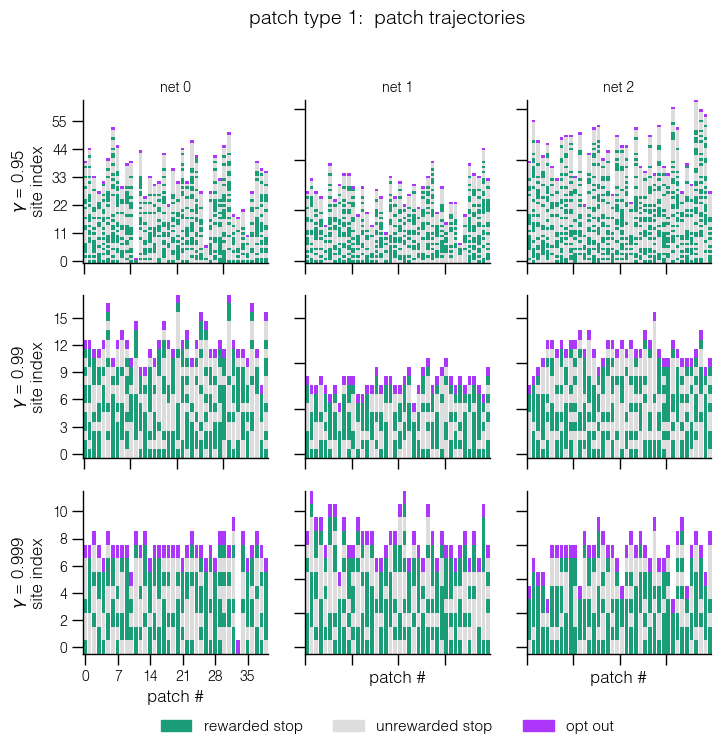

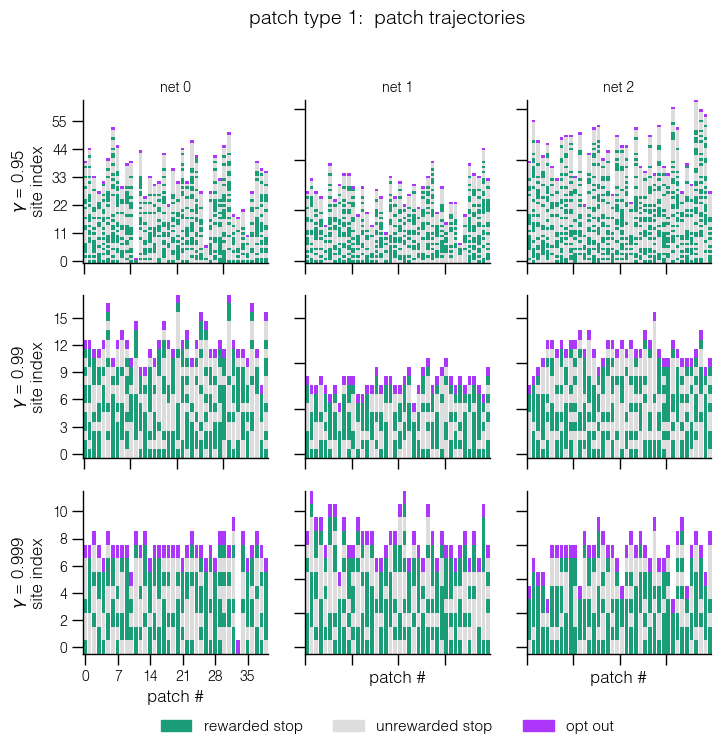

In [211]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=1, n_patches=40)

saved results/td_learning_sweep/patch_traj_gamma_patch2_np8_g0-0.9.svg


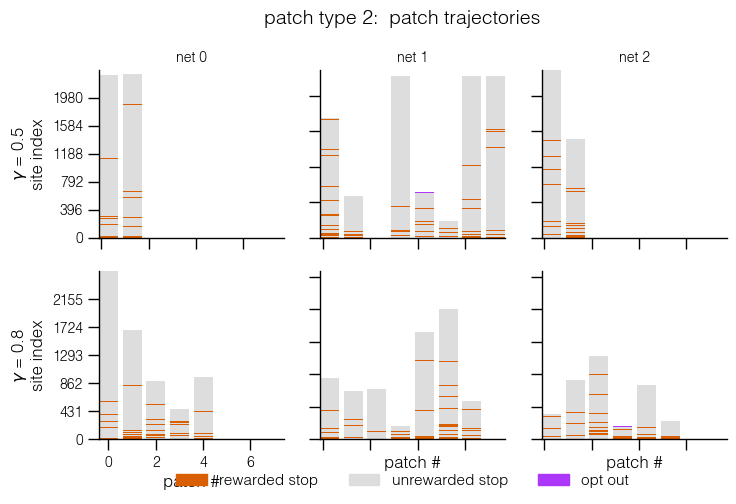

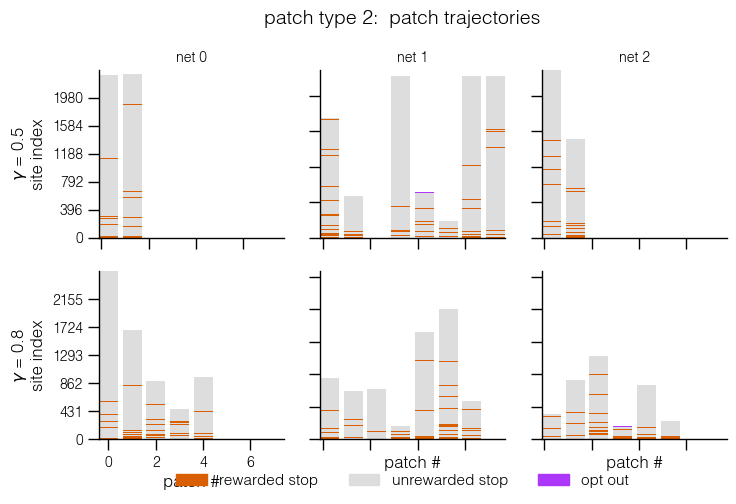

In [212]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=2, n_patches=8, gamma_min=0, gamma_max=0.9)

saved results/td_learning_sweep/patch_traj_gamma_patch2_np40_g0.95-1.svg


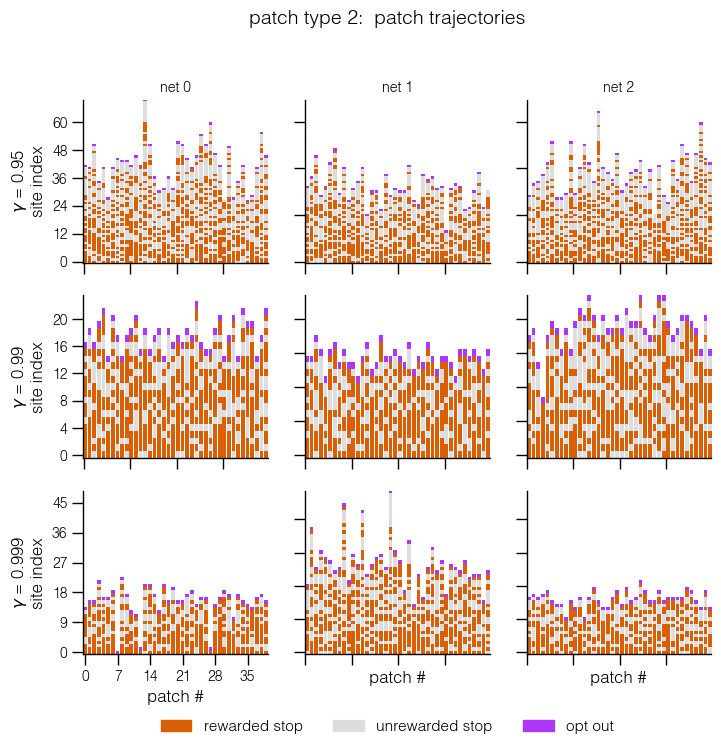

In [213]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=2, n_patches=40);

## Combination: trajectories + P(leave) heatmaps per gamma (one network)

3x3 grid for a single network: rows = gamma (0.95 / 0.99 / 0.999); columns = patch trajectories,
P(leave) vs consecutive fails, P(leave) vs cumulative fails.

In [214]:
def plot_combination(dfs_grid, gammas, patch_type, network=0, gamma_min=0.95, n_patches=40,
                     col_width=4, gap=1, min_n=5, cmap='YlGnBu', vmin=0, vmax=1,
                     label_fontsize=12, tick_fontsize=10, row_label='$\\gamma$'):
    """3x3 grid for a single network: rows = gamma (>= gamma_min), columns =
    [patch trajectories | P(leave) vs consecutive fails | P(leave) vs cumulative fails].
    vmin/vmax set the P(leave) heatmap color limits."""
    def _thin(vals, max_ticks=5):
        n = len(vals)
        if n == 0:
            return np.array([], int)
        return np.arange(0, n, max(1, int(np.ceil(n / max_ticks))))

    rows = [i for i, g in enumerate(gammas) if g >= gamma_min]
    gammas_sel = [gammas[i] for i in rows]
    dfs = [dfs_grid[i][network] for i in rows]
    nrows = len(rows)
    cat_colors = {2: odor_colors[patch_type], 1: '#dddddd', 0: '#ac37fa'}

    # column 0: patch-trajectory images (shared site axis, columns = patches, white gaps between)
    cmats = [patch_cat_matrix(df, patch_type, n_patches) for df in dfs]
    n_sites = max(m.shape[1] for m in cmats)

    def traj_img(M):
        P = np.full((n_patches, n_sites), -1, int); P[:, :M.shape[1]] = M
        base = np.ones((n_sites, n_patches, 3)); Pt = P.T
        for cat, col in cat_colors.items():
            base[Pt == cat] = mcolors.to_rgb(col)
        W = n_patches * col_width + (n_patches - 1) * gap
        img = np.ones((n_sites, W, 3))
        for p in range(n_patches):
            x = p * (col_width + gap)
            img[:, x:x + col_width, :] = base[:, p][:, None, :]
        return img

    # columns 1,2: P(leave) heatmaps -> shared cum-reward y across all, own x per column
    con = [leave_matrix(df, 'consecutive_misses', patch_type, min_n=min_n) for df in dfs]
    cum = [leave_matrix(df, 'cumulative_misses', patch_type, min_n=min_n) for df in dfs]
    yv = sorted(set().union(*(set(m.index) for m in con + cum)))
    cx = sorted(set().union(*(set(m.columns) for m in con)))
    ux = sorted(set().union(*(set(m.columns) for m in cum)))
    con = [m.reindex(index=yv, columns=cx) for m in con]
    cum = [m.reindex(index=yv, columns=ux) for m in cum]

    fig, axes = plt.subplots(nrows, 3, figsize=(3 * 3.2, nrows * 2.5),
                             gridspec_kw={'wspace': 0.55})
    axes = np.atleast_2d(axes)
    titles = ['patch trajectories', 'consecutive fails', 'cumulative fails']
    xlabels = ['patch #', 'consecutive fails', 'cumulative fails']
    for r in range(nrows):
        gamma = gammas_sel[r]
        ax0, ax1, ax2 = axes[r]
        ax0.imshow(traj_img(cmats[r]), aspect='auto', interpolation='nearest'); ax0.invert_yaxis()
        sns.heatmap(con[r], ax=ax1, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False); ax1.invert_yaxis()
        sns.heatmap(cum[r], ax=ax2, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False); ax2.invert_yaxis()
        for cc, ax in enumerate((ax0, ax1, ax2)):
            if r == 0:
                ax.set_title(titles[cc], fontsize=10)
            ax.set_xlabel(xlabels[cc] if r == nrows - 1 else '', fontsize=label_fontsize)
        ax0.set_ylabel(f'{row_label} = {gamma}\nsite index', fontsize=label_fontsize)
        ax1.set_ylabel('cum. rewards', fontsize=label_fontsize)
        ax2.set_ylabel('cum. rewards', fontsize=label_fontsize)

    format_plot(axes, ticklabelsize=tick_fontsize, axislabelsize=label_fontsize)

    for r in range(nrows):
        ax0, ax1, ax2 = axes[r]
        # col 0 trajectory: x = patch # (all rows), y = site index
        pidx = _thin(range(n_patches))
        ax0.set_xticks(pidx * (col_width + gap) + (col_width - 1) / 2)
        ax0.set_xticklabels([str(p) for p in pidx], fontsize=tick_fontsize)
        sidx = _thin(range(n_sites))
        ax0.set_yticks(sidx); ax0.set_yticklabels([str(s) for s in sidx], fontsize=tick_fontsize)
        # heatmaps: x = fails (own per column, all rows), y = cum rewards (shared, labeled on both)
        for ax, cols in ((ax1, cx), (ax2, ux)):
            xi = _thin(cols)
            ax.set_xticks(xi + 0.5)
            ax.set_xticklabels([f'{cols[i]:g}' for i in xi], fontsize=tick_fontsize, rotation=0)
        yi = _thin(yv)
        for ax in (ax1, ax2):
            ax.set_yticks(yi + 0.5)
            ax.set_yticklabels([f'{yv[i]:g}' for i in yi], fontsize=tick_fontsize)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax)); sm.set_array([])
    cb = fig.colorbar(sm, ax=axes[:, 1:].ravel().tolist(), fraction=0.02, pad=0.02, label='P(leave)')
    cb.outline.set_visible(False)
    handles = [mpatches.Patch(color=cat_colors[2], label='rewarded stop'),
               mpatches.Patch(color=cat_colors[1], label='unrewarded stop'),
               mpatches.Patch(color=cat_colors[0], label='opt out')]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
               fontsize=11, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'patch type {patch_type}  (net {network})', fontsize=14, y=1.01)
    save_svg(fig, f'combination_{_tag(row_label)}_patch{patch_type}_net{network}')
    plt.show()
    return fig

saved results/td_learning_sweep/combination_gamma_patch1_net0.svg


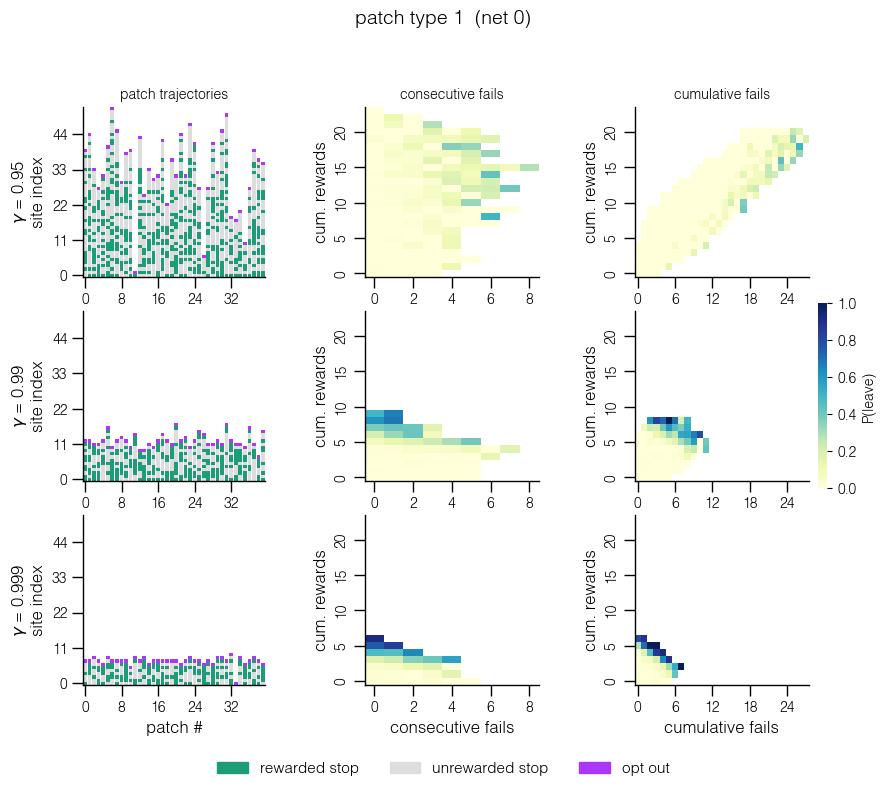

In [215]:
plot_combination(dfs_grid, GAMMAS, patch_type=1, network=0);

saved results/td_learning_sweep/combination_gamma_patch2_net0.svg


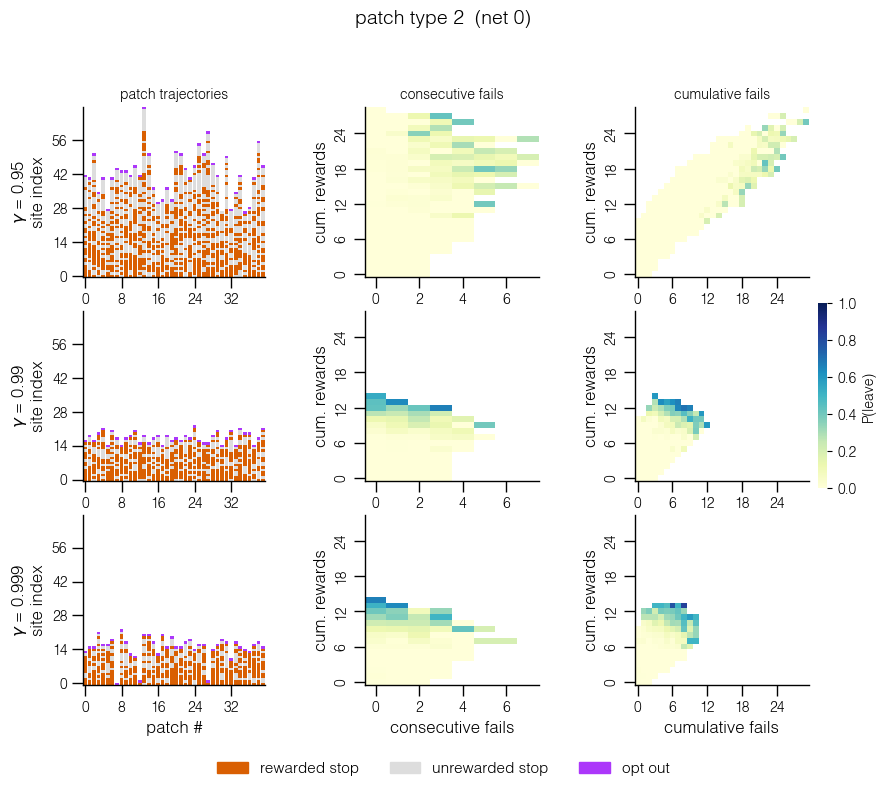

In [216]:
plot_combination(dfs_grid, GAMMAS, patch_type=2, network=0);

# n_steps sweep (bash_scripts/train_n_steps_sweep.sh)

The 50-step networks aren't finished; below are the completed **n_steps in {1, 5, 10, 20}** (12
networks), plotted the same way as the gamma sweep. Rows are n_steps_per_update, columns are the 3 networks.

In [217]:
# n_steps sweep: load the completed runs (n_steps in {1,5,10,20}; 50 not finished yet)
def nsteps_traj_path(n, net):
    exp = f'fixed_exp_gru_initial_prob_offset_n_steps_{n}_save30_net{net}'
    hits = sorted(glob.glob(f'{REPO}/results/{exp}/step_*/traj_*.pkl'))
    if not hits:
        raise FileNotFoundError(exp)
    return hits[-1]

N_STEPS_VALS = [1, 5, 10, 20]
paths_ns = [[nsteps_traj_path(n, net) for net in NETS] for n in N_STEPS_VALS]
dfs_grid_ns = [[load_odor_site_df(paths_ns[r][c], nn_num=c, brief=False)
                for c in range(len(NETS))] for r in range(len(N_STEPS_VALS))]
print('loaded', sum(len(row) for row in dfs_grid_ns), 'n_steps dataframes')

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
loaded 12 n_steps dataframes


## P(leave) heatmaps -- patch type 1

saved results/td_learning_sweep/leave_grid_n_steps_patch1_consecutive_misses.svg


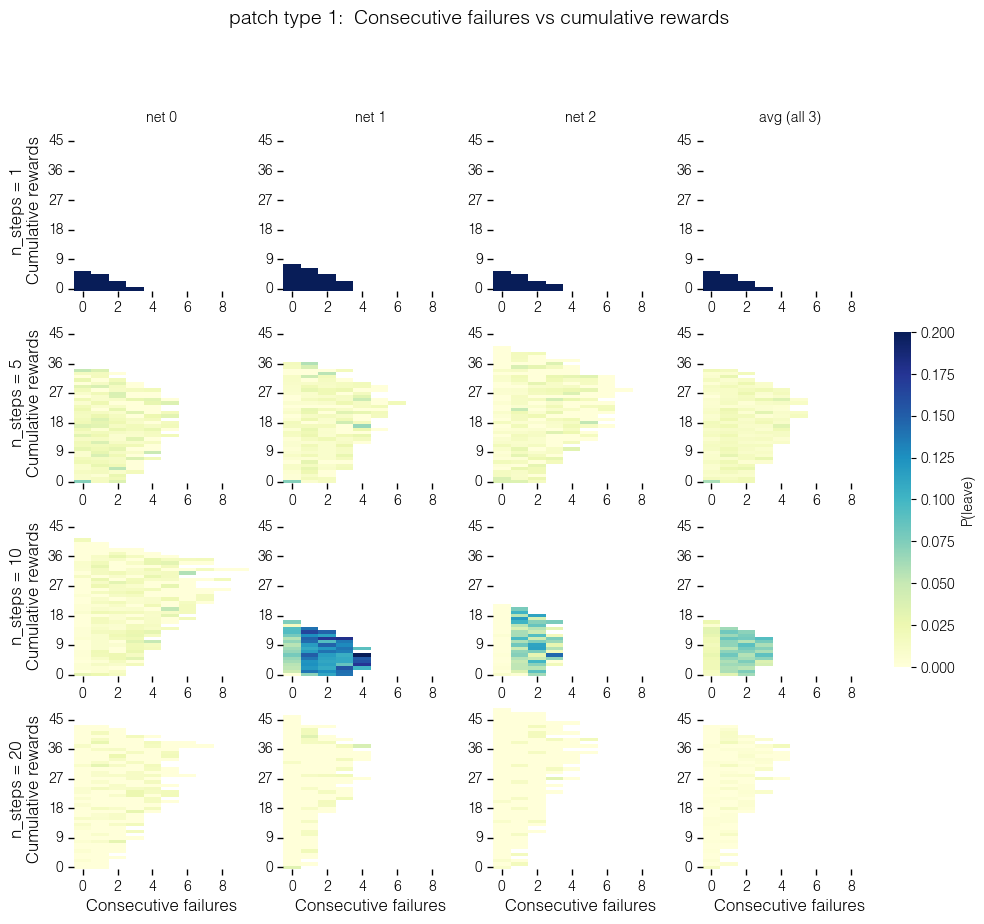

In [218]:
plot_leave_grid(dfs_grid_ns, N_STEPS_VALS, patch_type=1,
                x_col='consecutive_misses', x_label='Consecutive failures',
                gamma_min=0, row_label='n_steps', min_n=50, vmax=0.2);

saved results/td_learning_sweep/leave_grid_n_steps_patch1_cumulative_misses.svg


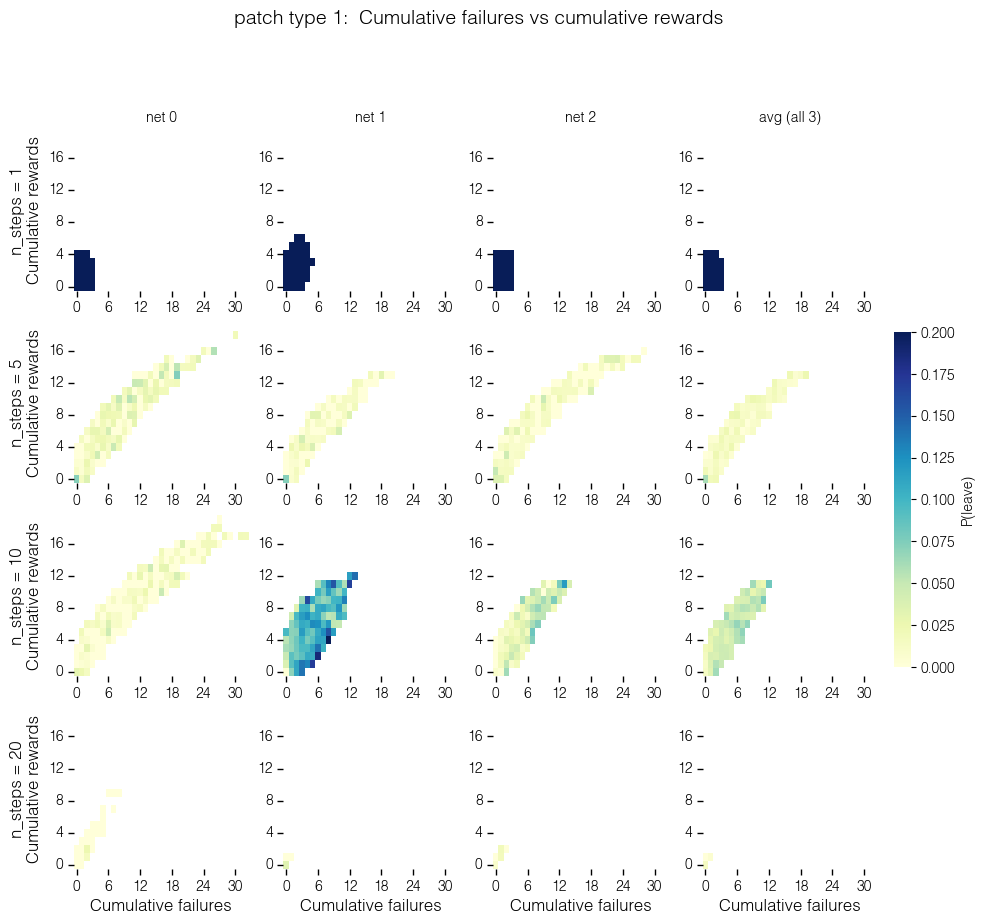

In [219]:
plot_leave_grid(dfs_grid_ns, N_STEPS_VALS, patch_type=1,
                x_col='cumulative_misses', x_label='Cumulative failures',
                gamma_min=0, row_label='n_steps', min_n=50, vmax=0.2);

## P(leave) heatmaps -- patch type 2

saved results/td_learning_sweep/leave_grid_n_steps_patch2_consecutive_misses.svg


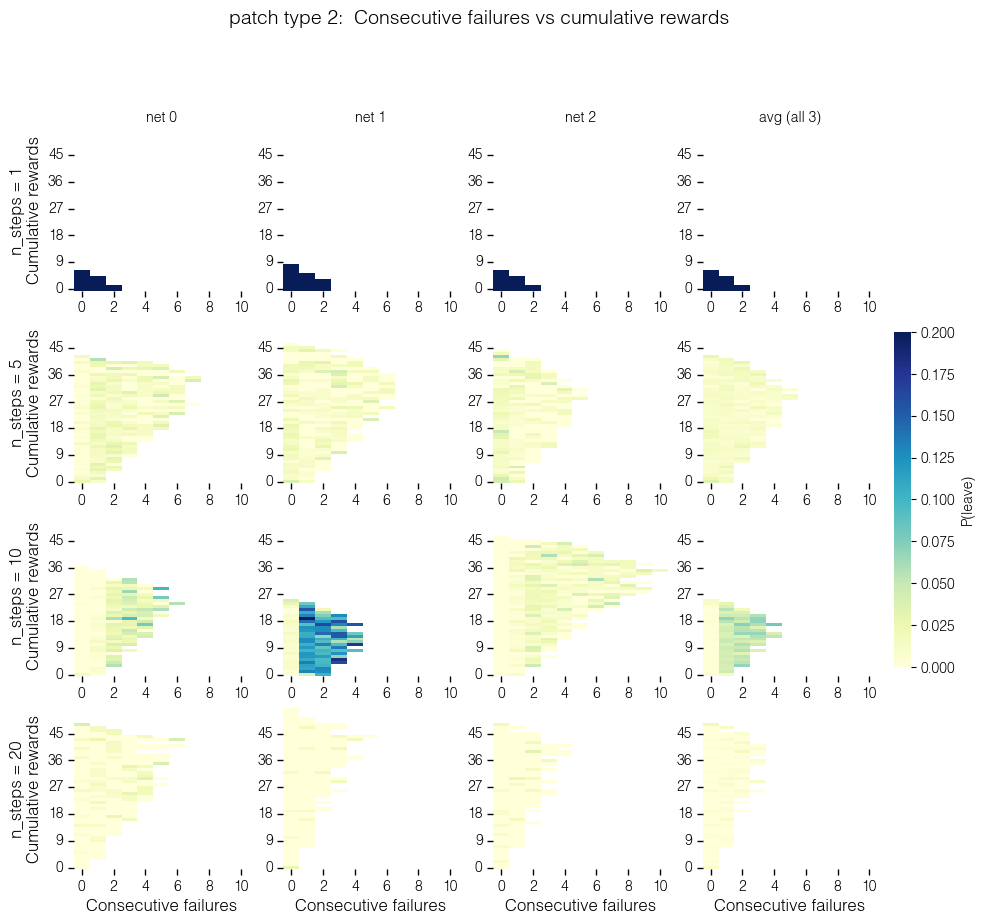

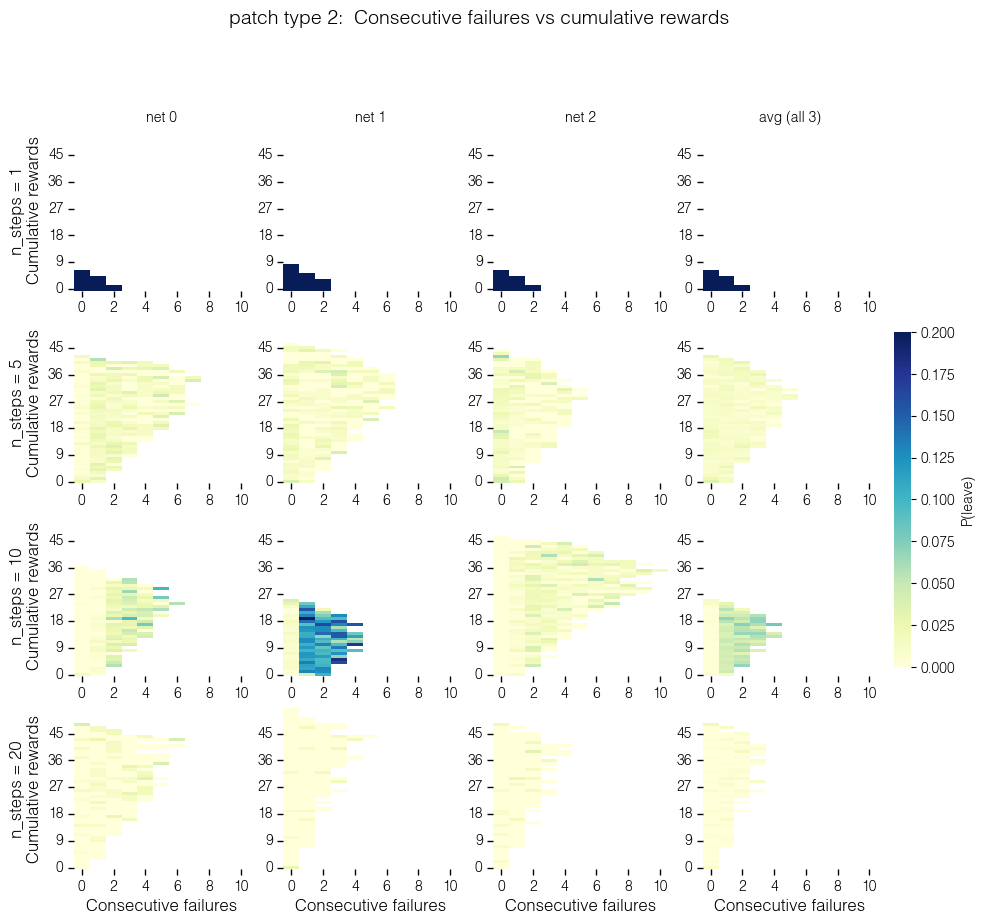

In [220]:
plot_leave_grid(dfs_grid_ns, N_STEPS_VALS, patch_type=2,
                x_col='consecutive_misses', x_label='Consecutive failures', gamma_min=0,
                row_label='n_steps', min_n=50, vmax=0.2)

saved results/td_learning_sweep/leave_grid_n_steps_patch2_cumulative_misses.svg


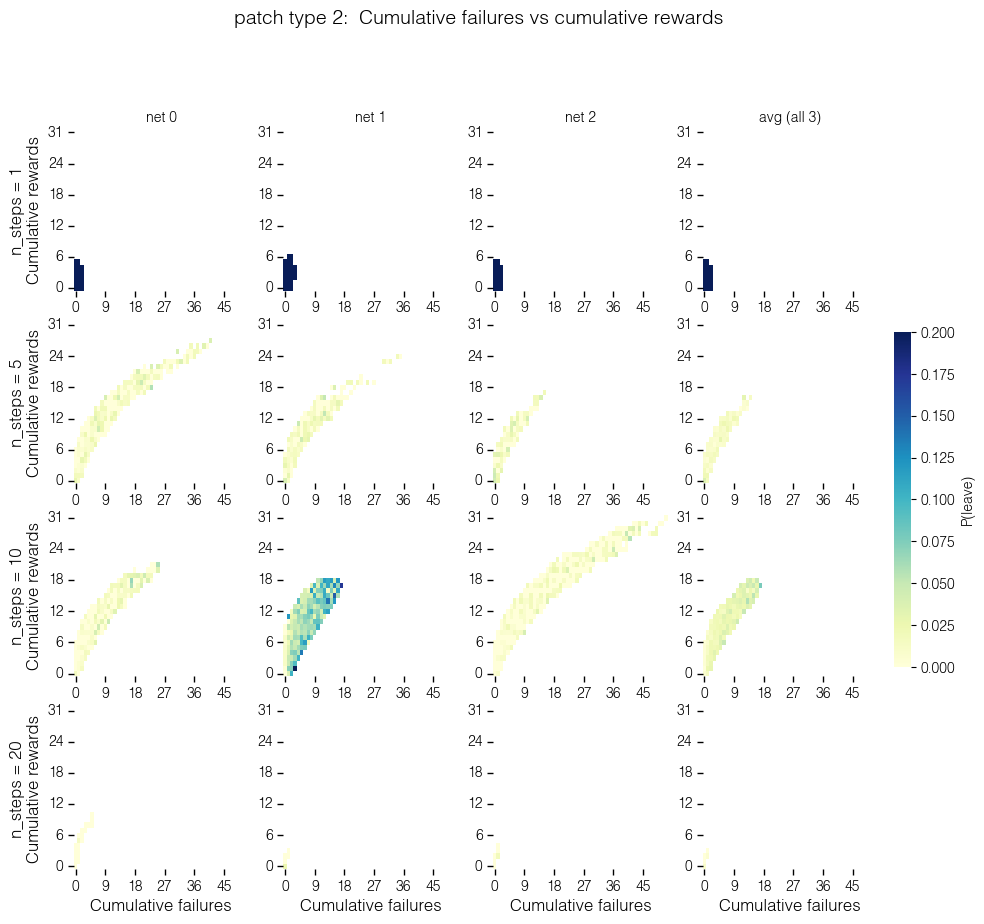

In [221]:
plot_leave_grid(dfs_grid_ns, N_STEPS_VALS, patch_type=2,
                x_col='cumulative_misses', x_label='Cumulative failures',
                gamma_min=0, row_label='n_steps', min_n=50, vmax=0.2);

## Patch trajectories

saved results/td_learning_sweep/patch_traj_n_steps_patch1_np40_g0-1e+09.svg


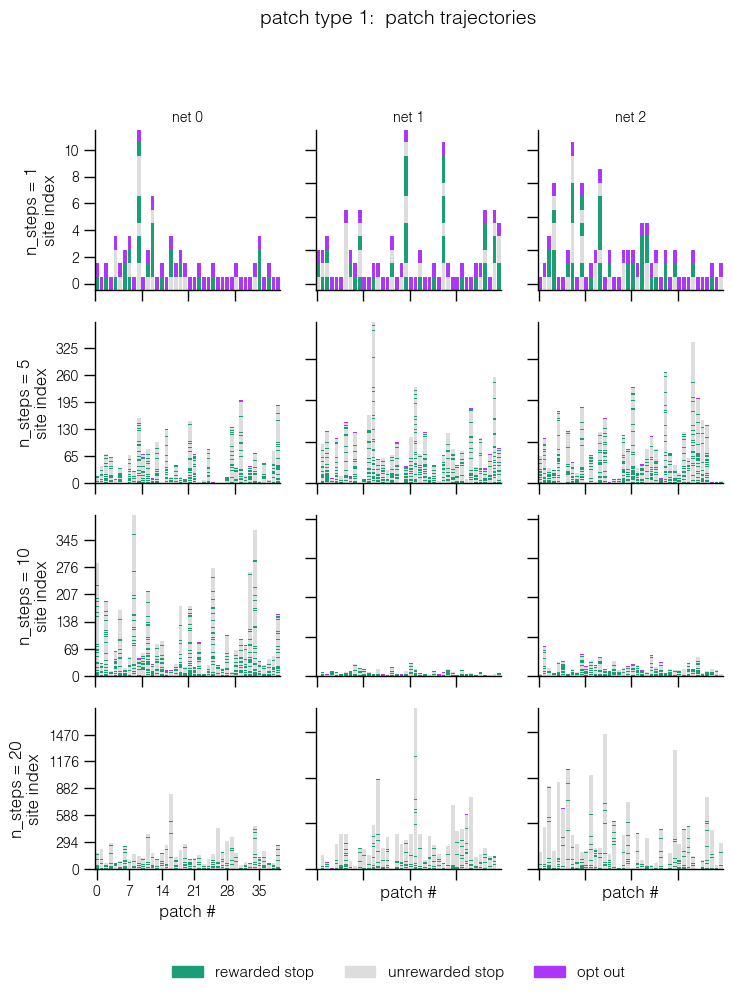

In [222]:
plot_patch_traj_grid(dfs_grid_ns, N_STEPS_VALS, patch_type=1, gamma_min=0, gamma_max=1e9, row_label='n_steps');

saved results/td_learning_sweep/patch_traj_n_steps_patch2_np40_g0-1e+09.svg


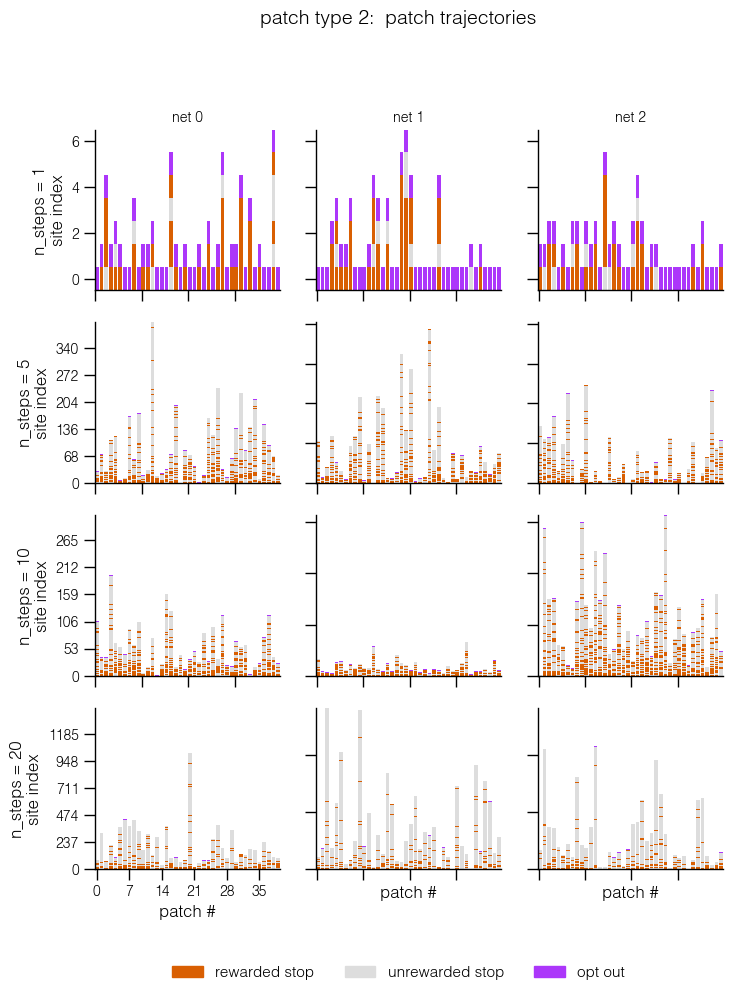

In [223]:
plot_patch_traj_grid(dfs_grid_ns, N_STEPS_VALS, patch_type=2, gamma_min=0, gamma_max=1e9, row_label='n_steps');

## Combination (net 0)

saved results/td_learning_sweep/combination_n_steps_patch1_net0.svg


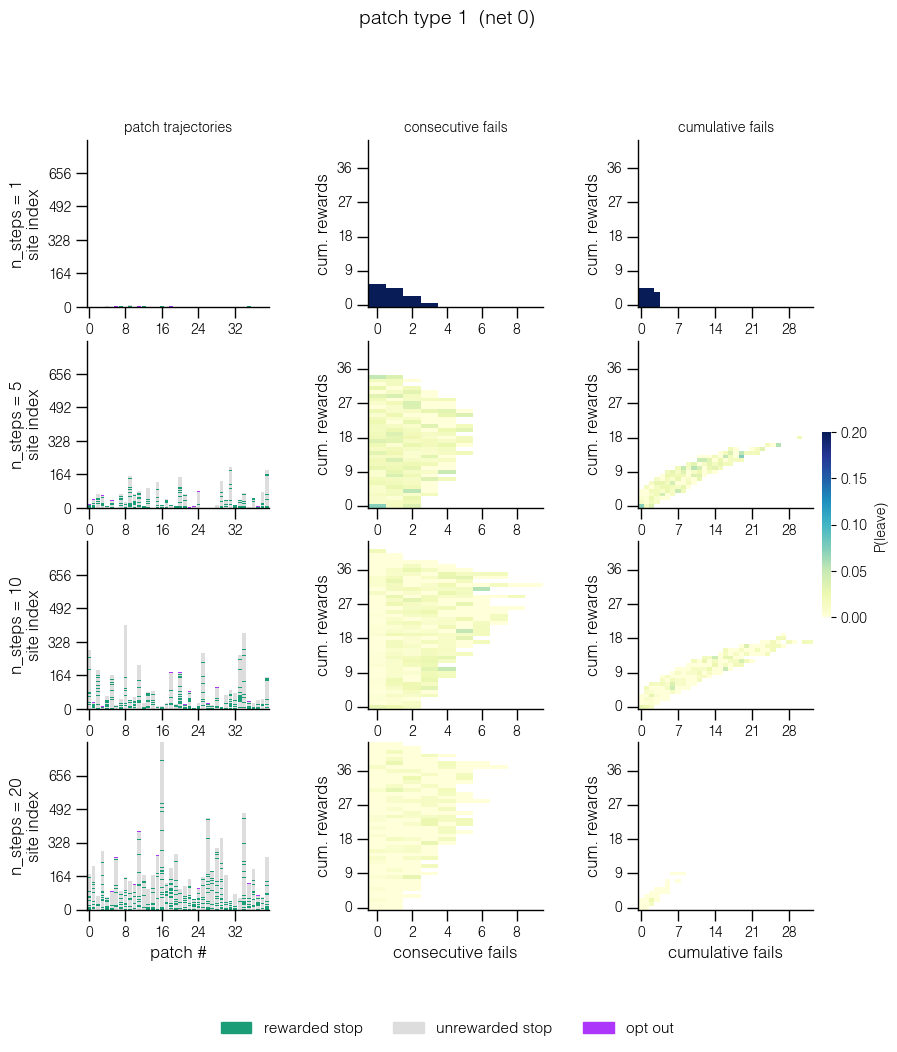

In [224]:
plot_combination(dfs_grid_ns, N_STEPS_VALS, patch_type=1, network=0, gamma_min=0, row_label='n_steps', min_n=50, vmax=0.2);

saved results/td_learning_sweep/combination_n_steps_patch2_net0.svg


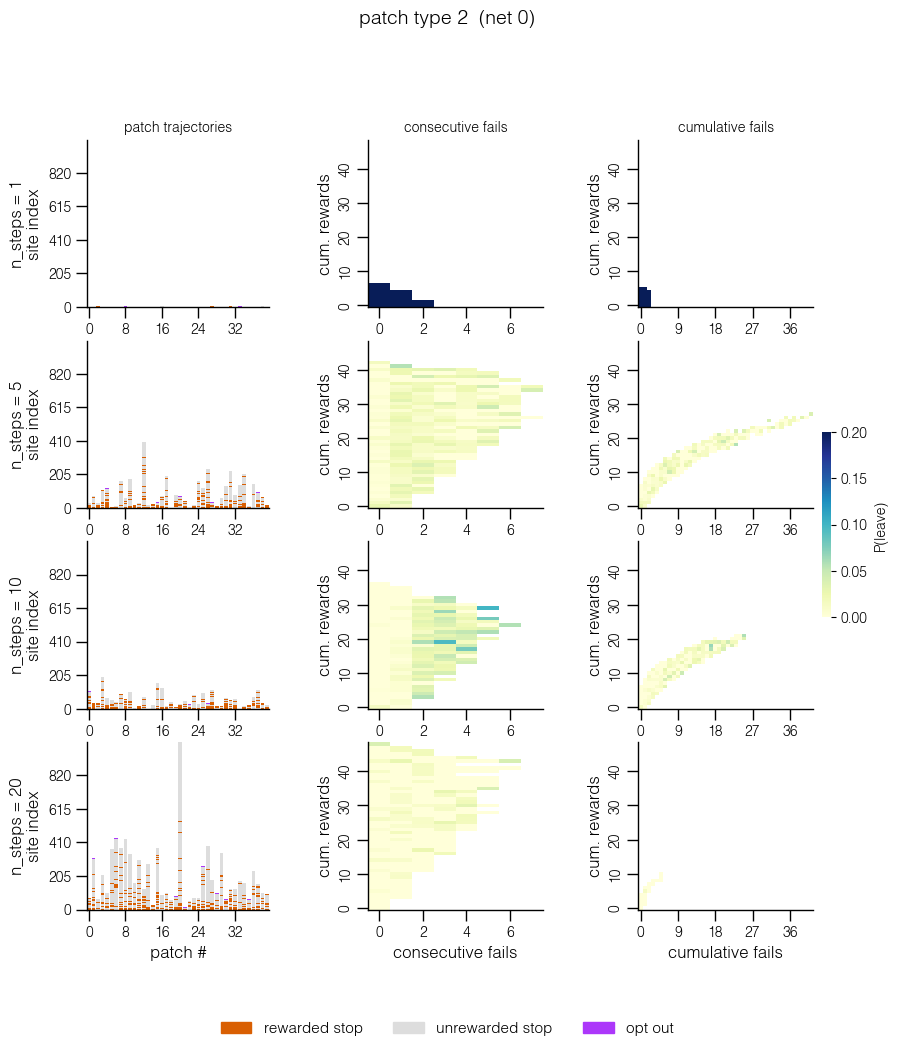

In [225]:
plot_combination(dfs_grid_ns, N_STEPS_VALS, patch_type=2, network=0, gamma_min=0, row_label='n_steps', min_n=50, vmax=0.2);

# Reward rate over training

For every network, the per-session mean reward rate (from `checkpoints/<exp>/_reward_rates/step_00/`)
plotted against session number. **Gamma sweep:** each network colored by its gamma (3 solid lines per
color). **n_steps sweep:** each network colored by its n_steps value.

In [226]:
# ---- Reward rate over training --------------------------------------------------------
# Per session, each run logged the per-update mean reward to
#   checkpoints/<exp>/_reward_rates/step_00/<session:06d>
# We take the mean over each session -> one reward-rate point per session (each session ~= 20000
# env steps for both sweeps, so the session axis is comparable across gamma and n_steps).
def load_reward_curve(exp, step='step_00'):
    files = sorted(glob.glob(f'{REPO}/checkpoints/{exp}/_reward_rates/{step}/*'))
    if not files:
        raise FileNotFoundError(f'no reward rates for {exp}')
    return np.array([np.load(f).mean() for f in files])   # (n_sessions,) per-session mean reward


def plot_reward_curves(series, val_label, title, cmap_name='viridis', smooth=1,
                       average=False, band=True, figsize=(4.2, 2.6),
                       label_fontsize=10, tick_fontsize=8):
    """series: list of (value, [exp_net0, exp_net1, ...]). One color per value.
    average=False: a solid line per network (the 3 same-value networks share a color).
    average=True:  one line per condition = mean across networks, with a +/-SEM band (band=True).
    Optional boxcar smoothing (`smooth` sessions)."""
    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap(cmap_name)
    n = len(series)
    for i, (v, exps) in enumerate(series):
        color = cmap(i / (n - 1)) if n > 1 else cmap(0.5)
        curves = []
        for exp in exps:
            c = load_reward_curve(exp)
            if smooth > 1:
                c = np.convolve(c, np.ones(smooth) / smooth, mode='valid')
            curves.append(c)
        if average:
            L = min(len(c) for c in curves)                 # align lengths (equal within a condition)
            stack = np.stack([c[:L] for c in curves])
            mean, x = stack.mean(0), np.arange(L)
            ax.plot(x, mean, color=color, lw=1.3, alpha=0.95, label=f'{val_label} = {v}')
            if band and stack.shape[0] > 1:
                sem = stack.std(0, ddof=1) / np.sqrt(stack.shape[0])
                ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2, linewidth=0)
        else:
            for j, c in enumerate(curves):
                ax.plot(np.arange(len(c)), c, color=color, lw=0.9, alpha=0.85,
                        label=f'{val_label} = {v}' if j == 0 else None)
    ax.set_xlabel('Session')
    ax.set_ylabel('Mean reward rate')
    ax.set_title(title, fontsize=11)
    # legend outside, to the right of the axes
    ax.legend(frameon=False, fontsize=7, title=val_label, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    format_plot(ax, ticklabelsize=tick_fontsize, axislabelsize=label_fontsize)
    plt.tight_layout()
    save_svg(fig, f'reward_rate_{_tag(val_label)}{"_avg" if average else ""}')
    plt.show()
    return fig

saved results/td_learning_sweep/reward_rate_gamma_avg.svg


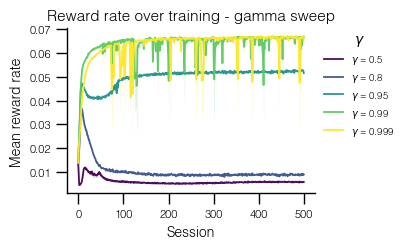

In [227]:
# gamma sweep: one color per gamma, a solid line per network (3 lines share a color).
gamma_series = [(g, [f'fixed_exp_gru_initial_prob_offset_gamma_{suf}_net{net}' for net in NETS])
                for g, suf in zip(GAMMAS, SUFFIXES)]
plot_reward_curves(gamma_series, r'$\gamma$', 'Reward rate over training - gamma sweep', average=True);

saved results/td_learning_sweep/reward_rate_n_steps_avg.svg


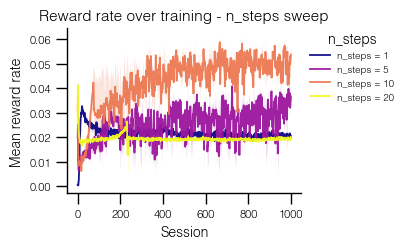

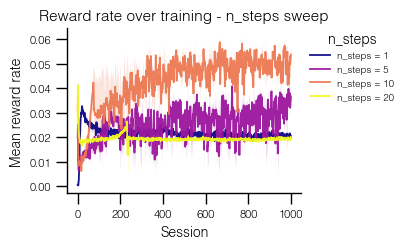

In [228]:
# n_steps sweep: one color per n_steps value, a solid line per network (3 lines share a color).
# Reward rates come from the ORIGINAL checkpoints (not the _save30 rollouts).
nstep_series = [(n, [f'fixed_exp_gru_initial_prob_offset_n_steps_{n}_net{net}' for net in NETS])
                for n in N_STEPS_VALS]
plot_reward_curves(nstep_series, 'n_steps', 'Reward rate over training - n_steps sweep',
                   cmap_name='plasma', average=True)